### Bayesian Interference

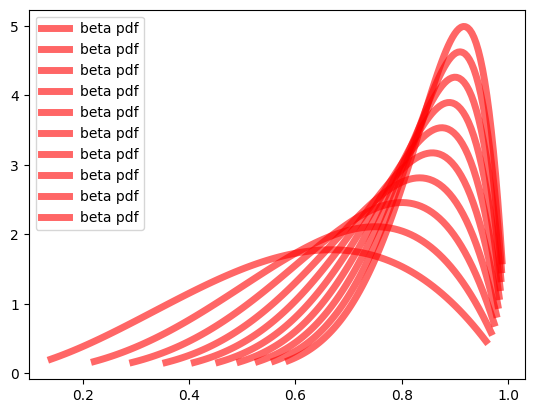

In [1]:
from scipy.stats import beta 
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(1, 1)


#initial count of heads
a = 2

#initial count of tails
b = 2

#support
lb, ub = beta.support(a,b)

def update_belief(a, b, outcome):
    #increments heads or tails 
    if outcome == 'H':
        a += 1
    elif outcome == 'T':
        b += 1
    return a, b

def plot_belief(a, b):
    x = np.linspace(beta.ppf(0.01, a, b), beta.ppf(0.99, a, b), 100)
    ax.plot(x, beta.pdf(x, a, b), 'r-', lw=5, alpha=0.6, label='beta pdf')

for i in range(10):
    a, b = update_belief(a, b, 'H')
    plot_belief(a, b)

plt.legend()
plt.show()

### Kalman Filter

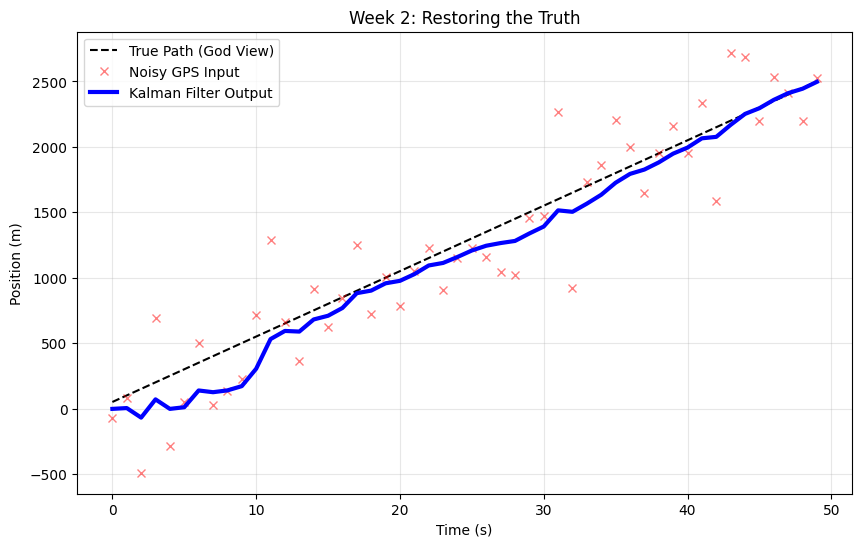

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

# 1. Simulate the "True" Path (Physics) and "Sensor" Readings (Noise)
np.random.seed(2)
time_steps = 50
dt = 1.0 # 1 second per step
velocity = 50 # m/s

true_positions = []
sensor_readings = []
current_pos = 0

for t in range(time_steps):
    # Physics: Move forward 50m
    current_pos += velocity
    true_positions.append(current_pos)
    
    # Noise: Add random garbage (+/- 300m variance)
    noise = np.random.normal(0, 300) 
    sensor_readings.append(current_pos + noise)

# 2. YOUR JOB: Configure the Kalman Filter
kf = KalmanFilter(dim_x=2, dim_z=1) # 2 Variables (Pos, Vel), 1 Sensor (Pos)

# INITIAL STATE (Where do we think we are?)
kf.x = np.array([0., 0.])       # Start at 0, Velocity 0

# STATE TRANSITION MATRIX (F) - The Physics
# Pos_new = Pos_old + (Vel_old * dt)
# Vel_new = Vel_old
kf.F = np.array([[1., dt],
                 [0., 1.]])

# MEASUREMENT FUNCTION (H) - What do we measure?
# We only measure Position (1st variable), not Velocity.
kf.H = np.array([[1., 0.]])

# COVARIANCE MATRICES (The "Trust" Knobs)
# P = Prediction Uncertainty (How unsure are we at the start?)
kf.P *= 1000. 
# R = Measurement Noise (How trash is the sensor?) -> HIGH value = Trust sensor less
kf.R = 50000.
# Q = Process Noise (How much does the driver buffet around?)
kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=0.1)

# 3. RUN THE FILTER
kalman_estimates = []

for z in sensor_readings:
    kf.predict()   # Step 1: Physics Guess
    kf.update(z)   # Step 2: Correct with Measurement
    kalman_estimates.append(kf.x[0]) # Store the Position estimate

# 4. PLOT
plt.figure(figsize=(10, 6))
plt.plot(true_positions, 'k--', label='True Path (God View)')
plt.plot(sensor_readings, 'rx', alpha=0.5, label='Noisy GPS Input')
plt.plot(kalman_estimates, 'b-', linewidth=3, label='Kalman Filter Output')
plt.legend()
plt.title("Week 2: Restoring the Truth")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.grid(True, alpha=0.3)
plt.show()

### Combined Example

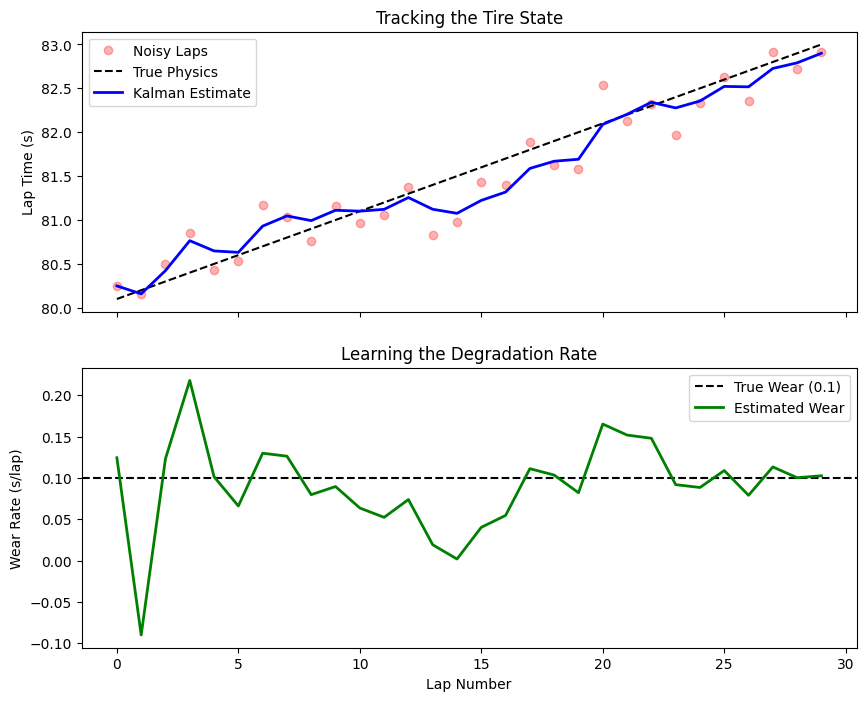

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

# --- 1. SIMULATION (The "Real World") ---
laps = 30
true_wear_rate = 0.1  # Tire loses 0.1s per lap
base_pace = 80.0      # Starts at 80s lap time
traffic_noise = 0.3   # Random variance

# Generate the "Actual" noisy lap times
actual_pace = []
perfect_pace = []
current_pace = base_pace

np.random.seed(42)
for i in range(laps):
    # Physics
    current_pace += true_wear_rate 
    perfect_pace.append(current_pace)
    
    # Noise
    noise = np.random.normal(0, traffic_noise)
    actual_pace.append(current_pace + noise)

# --- 2. THE KALMAN FILTER (The "Brain") ---
kf = KalmanFilter(dim_x=2, dim_z=1)

# State: [Current Pace, Wear Rate]
# We want to "Discover" that the Wear Rate is 0.1, purely from noisy data
kf.x = np.array([80.0, 0.0]) # Initial Guess: 80s pace, 0 degradation

# Transition Matrix (Physics)
# Pace_new = Pace_old + (Wear_Rate * 1)
# Wear_new = Wear_old (Assume constant wear for now)
kf.F = np.array([[1., 1.],
                 [0., 1.]])

# Measurement Function
# We only measure Pace (State[0]), not Wear Rate (State[1])
kf.H = np.array([[1., 0.]])

# Tuning the Knobs
kf.P *= 1000.  # High initial uncertainty
kf.R = 0.5     # High sensor noise (Traffic is bad)
kf.Q = Q_discrete_white_noise(dim=2, dt=1, var=0.01) # Small process noise

# --- 3. RUN IT ---
estimates = []
wear_rate_estimates = []

for measure in actual_pace:
    kf.predict()
    kf.update(measure)
    estimates.append(kf.x[0])
    wear_rate_estimates.append(kf.x[1])

# --- 4. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top: Pace Tracking
ax1.plot(actual_pace, 'ro', alpha=0.3, label='Noisy Laps')
ax1.plot(perfect_pace, 'k--', label='True Physics')
ax1.plot(estimates, 'b-', linewidth=2, label='Kalman Estimate')
ax1.set_ylabel("Lap Time (s)")
ax1.legend()
ax1.set_title("Tracking the Tire State")

# Bottom: The "Hidden" Variable (Wear Rate)
ax2.axhline(true_wear_rate, color='k', linestyle='--', label='True Wear (0.1)')
ax2.plot(wear_rate_estimates, 'g-', linewidth=2, label='Estimated Wear')
ax2.set_ylabel("Wear Rate (s/lap)")
ax2.set_xlabel("Lap Number")
ax2.legend()
ax2.set_title("Learning the Degradation Rate")

plt.show()